# Gợi ý Lọc cộng tác - User-Based KNN dựa trên vector nhúng FastRP

## Introduction

Sử dụng Fast Random Projection để tạo các vector nhúng (embeddings) cho các nút Poi và User, sau đó dùng thuật toán K-Nearest Neighbors để tính toán độ tương đồng giữa các nút User.

Khi gợi ý, tìm các người dùng tương đồng nhất và gợi ý các POI khác mà họ cũng quan tâm.

[Thuật toán K-Nearest Neighbors (kNN)](https://neo4j.com/docs/graph-data-science/current/algorithms/knn/): xác định các nút tương đồng và đưa ra gợi ý dựa trên đó.

[FastRP](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp/): tận dụng thông tin cấu trúc đồ thị trong kNN bằng cách tạo các vector nhúng nút trước.

## Điều kiện tiên quyết

Neo4j server đã được cài đặt phiên bản GDS mới (2.0+).

Thư viện Python `graphdatascience` để vận hành Neo4j GDS.

Truy vấn `Cypher` để tạo các gợi ý.

In [1]:
import os
import configparser

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from graphdatascience import GraphDataScience

d:\Thac_Si\De_an_thac_si\code\KG-Rec-Sys-Tourism-SG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sử dụng file ini cho thông tin đăng nhập, nếu không sử dụng mặc định
HOST = 'neo4j://localhost'
USERNAME = 'neo4j'
DATABASE = 'neo4j'
PASSWORD = 'password'

NEO4J_CONF_FILE = 'neo4j.ini'

if NEO4J_CONF_FILE is not None and os.path.exists(NEO4J_CONF_FILE):
    config = configparser.RawConfigParser()
    config.read(NEO4J_CONF_FILE)
    HOST = config['NEO4J']['HOST']
    DATABASE = config['NEO4J'].get('DATABASE', 'neo4j')
    USERNAME = config['NEO4J'].get('USERNAME', DATABASE)
    PASSWORD = config['NEO4J']['PASSWORD']
    print(f'Using custom database properties \nHOST: {HOST}; DATABASE: {DATABASE}; PASSWORD: {PASSWORD}')
else:
    print('Could not find database properties file, using defaults')

# Kết nối với cơ sở dữ liệu Neo4j bằng thư viện GDS
gds = GraphDataScience(HOST, auth=(USERNAME, PASSWORD))
gds.set_database(DATABASE)

Using custom database properties 
HOST: neo4j://127.0.0.1:7687; DATABASE: neo4j; PASSWORD: 12345678


## Chiếu (Projecting) đồ thị vào GDS

Chiếu đồ thị vào bộ nhớ (in-memory) để GDS có thể thao tác và phân tích dữ liệu

In [3]:
# định nghĩa cách chiếu cơ sở dữ liệu vào GDS
node_projection = ["User", "Poi"]
relationship_projection = {"REVIEWED": {"orientation": "UNDIRECTED", "properties": "rating"}}

# Trước khi chiếu thực tế, ước lượng lượng bộ nhớ cần thiết
result = gds.graph.project.estimate(node_projection, relationship_projection)

print(f"Required memory for native loading: {result['requiredMemory']}")

Required memory for native loading: [5515 KiB ... 5707 KiB]


In [5]:
# Kiểm tra và xóa đồ thị 'myGraph' đã tồn tại trong bộ nhớ trước khi chiếu
if gds.graph.exists("myGraph")["exists"]:
    gds.graph.drop(gds.graph.get("myGraph"))

# tiến hành chiếu đồ thị
G, result = gds.graph.project("myGraph", node_projection, relationship_projection)
print(f"The projection took {result['projectMillis']} ms")

# các phương thức trên `G` để kiểm tra xem đồ thị được chiếu có đúng không
print(f"Graph '{G.name()}' node count: {G.node_count()}")
print(f"Graph '{G.name()}' edge count: {G.relationship_count()}")
print(f"Graph '{G.name()}' node labels: {G.node_labels()}")

The projection took 2827 ms
Graph 'myGraph' node count: 24641
Graph 'myGraph' edge count: 47896
Graph 'myGraph' node labels: ['User', 'Poi']


## Tạo các vector nhúng nút bằng FastRP

Để thực hiện lọc cộng tác, tạo các vector nhúng nút nắm bắt thông tin cấu trúc từ đồ thị, làm đầu vào cho KNN sau này.

`embeddingDimension` được thiết lập là 256 cho đồ thị có hơn 24k nút. 

Chạy chế độ mutate của FastRP để ghi thuộc tính nhúng trực tiếp vào đồ thị được chiếu.

[phần cú pháp của tài liệu FastRP](https://neo4j.com/docs/graph-data-science/current/machine-learning/node-embeddings/fastrp/#algorithms-fastrp-syntax) 

In [5]:
# ước lượng bộ nhớ khi chạy các thuật toán như FastRP
result = gds.fastRP.mutate.estimate(
    G,
    randomSeed=42,
    embeddingDimension=256,
    relationshipWeightProperty="rating",
    iterationWeights=[0, 1, 1, 1],
    mutateProperty="embedding"
)

print(f"Dung lượng bộ nhớ cần thiết để chạy FastRP: {result['requiredMemory']}")

Dung lượng bộ nhớ cần thiết để chạy FastRP: 74 MiB


In [6]:
# chạy FastRP và đột biến (mutate) đồ thị được chiếu của chúng ta với kết quả
result = gds.fastRP.mutate(
    G,
    randomSeed=42,
    embeddingDimension=256,
    relationshipWeightProperty="rating",
    iterationWeights=[0, 1, 1, 1],
    mutateProperty="embedding"
)

print(f"Số lượng embedding vectors được tạo ra: {result['nodePropertiesWritten']}")

Số lượng embedding vectors được tạo ra: 24641


## Similarities with UserkNN

Xác định các nút tương đồng bằng cách sử dụng các vector nhúng nút được tạo bởi FastRP làm thuộc tính `nodeProperties`. 

Sử dụng chế độ write của thuật toán để ghi ngược các thuộc tính và quan hệ vào cơ sở dữ liệu, phân tích chúng sau bằng Cypher.

[phần cú pháp của tài liệu KNN](https://neo4j.com/docs/graph-data-science/current/algorithms/knn/#algorithms-knn-syntax) 

In [7]:
def topK_tuning():
    
    top_k_list = []

    for k in range(1,30):
        result = gds.knn.write(
        G, # Tham số đầu vào
        topK=k, # Top K số lượng láng giềng gần nhất
        nodeLabels=['User'], # Nhãn
        nodeProperties=["embedding"], # Thuộc tính vector đặc trưng
        randomSeed=42,
        concurrency=1, # Số luồng xử lý đồng thời
        sampleRate=1.0, #  Tỷ lệ lấy mẫu (0.0 đến 1.0) => Lấy 100% nút user
        deltaThreshold=0.0, # Ngưỡng hội tụ tối thiểu
        writeRelationshipType="CF_SIMILAR_USER"+str(k), # Nhãn mối quan hệ
        writeProperty="score", # Tên thuộc tính của mối quan hệ để lưu giá trị tương đồng

        )
        print(f"topK = {k}")
        print(f"Relationships produced: {result['relationshipsWritten']}")
        print(f"Nodes compared: {result['nodesCompared']}")
        print(f"Mean similarity: {result['similarityDistribution']['mean']}")

        top_k_list.append([k, result['similarityDistribution']['mean']])
    
    return top_k_list

In [8]:
top_k_list = topK_tuning() 

# thời gian chạy của hàm này sẽ mất khoảng 10 phút,
# Của tác giả
#top_k_list = [[1, 0.9939157612910378], [2, 0.9940597938502739], [3, 0.9944219534603936], [4, 0.9950116373318112], [5, 0.995537629312202], [6, 0.9961105275531317], [7, 0.9967810126999498], [8, 0.9969744809536875], [9, 0.9969924254699816], [10, 0.9973689662324101], [11, 0.9975579028765029], [12, 0.9976186487680783], [13, 0.997599921147859], [14, 0.9975682017576685], [15, 0.997567785239302], [16, 0.9975008765978366], [17, 0.997444304685102], [18, 0.9973874168012433], [19, 0.9973184783989875], [20, 0.9972443387961036], [21, 0.9971741445220691], [22, 0.9971201321036134], [23, 0.9970621580886316], [24, 0.9969813260360726], [25, 0.9968963513631868], [26, 0.9968325522809519], [27, 0.9967747525277024], [28, 0.996695660040167], [29, 0.9966159894369206]]

# Của tôi
# Thực nghiệm lần 1: embeddingDimension = 256 chiều
# Hội tụ ở epoch thứ 9: 0.9592121567670037
# top_k_list = [[1, 0.9265288233139936], [2, 0.9337202363855699], [3, 0.9391582258635877], [4, 0.9420667704413919], [5, 0.9451328262867648], [6, 0.9496567264631682], [7, 0.9538497939165901], [8, 0.957614389890783], [9, 0.9592121567670037], [10, 0.9587572553208294], [11, 0.9573759395497368], [12, 0.9552678403368183], [13, 0.9529725563290972], [14, 0.9501538339310334], [15, 0.9477800320614086], [16, 0.9452893981821396], [17, 0.9428898110148816], [18, 0.940482195456511], [19, 0.9380407884910749], [20, 0.9357453138284122], [21, 0.9334654764982164], [22, 0.9311837113569127], [23, 0.9289849768831296], [24, 0.9268531351500866], [25, 0.9247115699606503], [26, 0.9226946158430696], [27, 0.9207017281659029], [28, 0.9187240679508498], [29, 0.9167707741882448]]

# Thực nghiệm lần 2: embeddingDimension = 128 chiều
# Giảm số chiều embeddingDimension do chỉ có tổng 23k nút so với 50k nút của tác giả, giảm nhiễu dữ liệu trong tính toán cosine similarity
# Hội tụ ở epoch thứ 10: 0.9624565046422622
# top_k_list = [[1, 0.9319308326272403], [2, 0.9395381370993221], [3, 0.9436255923402076], [4, 0.9451390818427591], [5, 0.9499936919088925], [6, 0.9521270546109069], [7, 0.9577525099041081], [8, 0.9611709271599265], [9, 0.9624224807838988], [10, 0.9624565046422622], [11, 0.9608025239832261], [12, 0.9588924310721603], [13, 0.9566341172300313], [14, 0.9542089913119789], [15, 0.951905124021044], [16, 0.949676732153051], [17, 0.9474954559537366], [18, 0.9452102942074047], [19, 0.9430255041919625], [20, 0.9408711446874282], [21, 0.9387325235233254], [22, 0.936688863213687], [23, 0.9346666886351602], [24, 0.9327069264505424], [25, 0.930765810783835], [26, 0.9288878223540017], [27, 0.9270755562111184], [28, 0.9252615127371139], [29, 0.9234883065616383]]

# Thực nghiệm lần 3: embeddingDimension = 128 chiều (Bộ dữ liệu crawl lại)
# top_k_list = [[1, 0.9369910558512198], [2, 0.9404086316775582], [3, 0.9462385197447896], [4, 0.9494572585103883], [5, 0.9524342349770761], [6, 0.9557468571798248], [7, 0.9607744393266081], [8, 0.9639998498165409], [9, 0.965576183328935], [10, 0.9648056994372625], [11, 0.9631495731225147], [12, 0.9612806964474274], [13, 0.9594562975665402], [14, 0.9571941006931054], [15, 0.9550102555670705], [16, 0.9529070881591446], [17, 0.9507013579504909], [18, 0.9485710086176734], [19, 0.9463953337386851], [20, 0.9443075686800851], [21, 0.9422324949344018], [22, 0.940244210781979], [23, 0.9382506296632704], [24, 0.9363456825028462], [25, 0.934466844960051], [26, 0.9325726075871861], [27, 0.9307673559552495], [28, 0.928960463564548], [29, 0.9271938331225889]]

# Thực nghiệm lần 4: embeddingDimension = 256 chiều (Bộ dữ liệu crawl lại)
# top_k_list = [[1, 0.9313312350655004], [2, 0.9363632040182638], [3, 0.9410105480433014], [4, 0.9443646647743907], [5, 0.9477652958640185], [6, 0.9515235499096342], [7, 0.9565874461438021], [8, 0.9603313241574285], [9, 0.9614082358896174], [10, 0.9613485466144802], [11, 0.9602444537762344], [12, 0.9585114651694235], [13, 0.956056497910071], [14, 0.953527059670424], [15, 0.9512458729324502], [16, 0.9489056463060372], [17, 0.9464011721737288], [18, 0.9440130852545591], [19, 0.9417128990153841], [20, 0.9394203497170563], [21, 0.9371588950568738], [22, 0.9349850513766645], [23, 0.9328279949564415], [24, 0.9307675691232212], [25, 0.928662644116274], [26, 0.926651818322207], [27, 0.9246454043999053], [28, 0.9226813308387543], [29, 0.920763090700609]]
print(top_k_list)

 Knn: 100%|██████████| 100.0/100 [00:07<00:00, 13.56%/s, status: FINISHED]                                


topK = 1
Relationships produced: 21315
Nodes compared: 21315
Mean similarity: 0.9313312350655004


 Knn: 100%|██████████| 100.0/100 [00:07<00:00, 13.07%/s, status: FINISHED]                                               


topK = 2
Relationships produced: 42630
Nodes compared: 21315
Mean similarity: 0.9363632040182638


 Knn: 100%|██████████| 100.0/100 [00:06<00:00, 14.00%/s, status: FINISHED]                                


...

topK = 27
Relationships produced: 575505
Nodes compared: 21315
Mean similarity: 0.9246454043999053


 Knn: 100%|██████████| 100.0/100 [00:23<00:00,  4.16%/s, status: FINISHED]                                              


topK = 28
Relationships produced: 596820
Nodes compared: 21315
Mean similarity: 0.9226813308387543


 Knn: 100%|██████████| 100.0/100 [00:25<00:00,  3.92%/s, status: FINISHED]                               

topK = 29
Relationships produced: 618135
Nodes compared: 21315
Mean similarity: 0.920763090700609
[[1, 0.9313312350655004], [2, 0.9363632040182638], [3, 0.9410105480433014], [4, 0.9443646647743907], [5, 0.9477652958640185], [6, 0.9515235499096342], [7, 0.9565874461438021], [8, 0.9603313241574285], [9, 0.9614082358896174], [10, 0.9613485466144802], [11, 0.9602444537762344], [12, 0.9585114651694235], [13, 0.956056497910071], [14, 0.953527059670424], [15, 0.9512458729324502], [16, 0.9489056463060372], [17, 0.9464011721737288], [18, 0.9440130852545591], [19, 0.9417128990153841], [20, 0.9394203497170563], [21, 0.9371588950568738], [22, 0.9349850513766645], [23, 0.9328279949564415], [24, 0.9307675691232212], [25, 0.928662644116274], [26, 0.926651818322207], [27, 0.9246454043999053], [28, 0.9226813308387543], [29, 0.920763090700609]]


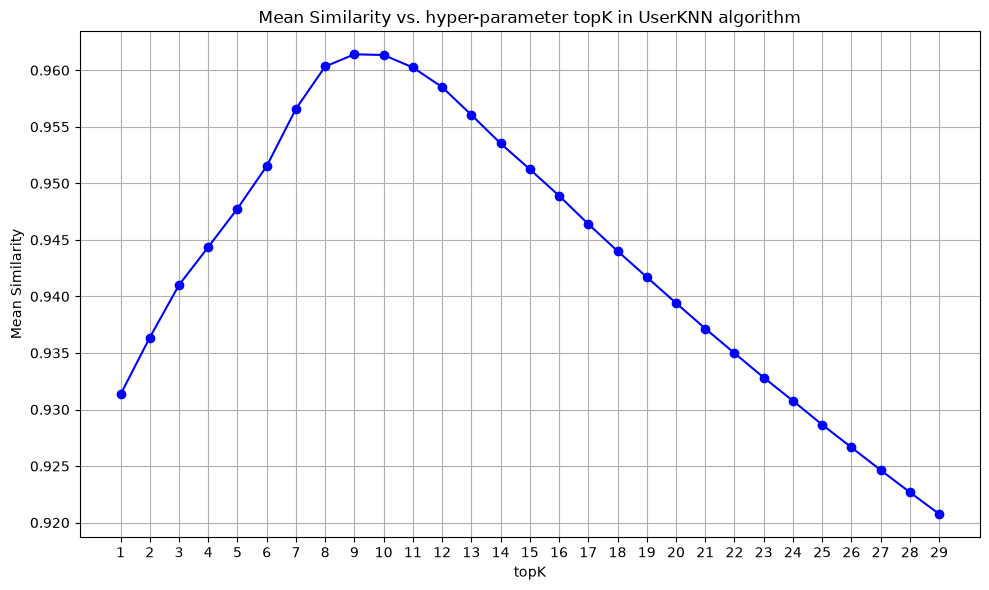

In [9]:
# trực quan hóa xu hướng Mean Similarity so với topK

# Chuyển đổi danh sách thành DataFrame
df_topK = pd.DataFrame(top_k_list, columns=['topK', 'mean_similarity'])

# Vẽ biểu đồ đường
plt.figure(figsize=(10, 6))
plt.plot(df_topK['topK'], df_topK['mean_similarity'], marker='o', color='b', linestyle='-')
plt.title('Mean Similarity vs. hyper-parameter topK in UserKNN algorithm')
plt.xlabel('topK')
plt.ylabel('Mean Similarity')
plt.grid(True)
plt.xticks(df_topK['topK'])
plt.tight_layout()
plt.show()

In [10]:
# tìm topK tốt nhất

# Tìm chỉ mục của dòng có mean_similarity lớn nhất
max_index = df_topK['mean_similarity'].idxmax()

# Lấy giá trị topK tương ứng với mean_similarity lớn nhất
topK_best = df_topK.loc[max_index, 'topK']

print("Giá trị TopK có mean_similarity tối đa:", topK_best)


Giá trị TopK có mean_similarity tối đa: 9


In [11]:
# Tính tương đồng với User-based KNN

# Chuyển KNN với siêu tham số topK tối ưu và ghi ngược lại DB
# thời gian chạy: ~50 giây

topK_best = 9

result = gds.knn.write(
    G,
    topK=topK_best,
    nodeLabels=['User'],
    nodeProperties=["embedding"],
    randomSeed=42,
    concurrency=1,
    sampleRate=1.0,
    deltaThreshold=0.0,
    writeRelationshipType="CF_SIMILAR_USER",
    writeProperty="score",

)

print(f"Relationships produced: {result['relationshipsWritten']}")
print(f"Nodes compared: {result['nodesCompared']}")
print(f"Mean similarity: {result['similarityDistribution']['mean']}")

 Knn: 100%|██████████| 100.0/100 [00:10<00:00,  9.70%/s, status: FINISHED]                                             

Relationships produced: 191835
Nodes compared: 21315
Mean similarity: 0.9614082358896174


Như chúng ta có thể thấy, độ tương đồng trung bình giữa các nút khá cao. Điều này là do có một số lượng lớn người dùng chỉ đánh giá 5 sao cho đúng 1 POI, hành vi của những người dùng này thưa thớt và sẽ được coi là tương đồng, dẫn đến các vector nhúng FastRP rất giống nhau.

## Khám phá kết quả

Kiểm tra kết quả gọi kNN bằng cách sử dụng Cypher. 

Sử dụng kiểu quan hệ `SIMILARITY` để lọc ra các mối quan hệ.

In [12]:
# tìm độ tương đồng lớn nhất giữa các người dùng
gds.run_cypher(
    """
        MATCH (u1:User)-[r:CF_SIMILAR_USER]->(u2:User)
        RETURN u1.name AS user1, u2.name AS user2, r.score AS similarity
        ORDER BY similarity DESCENDING, user1, user2
        LIMIT 10
    """
)

,user1,user2,similarity
0,Gojoban,blacklemongig,1.0
1,Gojoban,doanv218,1.0
2,blacklemongig,Gojoban,1.0
3,doanv218,Gojoban,1.0
4,148caleighg,LoveIreland49,1.0
5,154li_mk,940th_m,1.0
6,154li_mk,BoardingPass794415,1.0
7,154li_mk,Explore02774905628,1.0
8,154li_mk,Journey26708222876,1.0
9,154li_mk,Tourist39444667425,1.0


In [13]:
# tìm độ tương đồng nhỏ nhất giữa các người dùng
gds.run_cypher(
    """
        MATCH (u1:User)-[r:CF_SIMILAR_USER]->(u2:User)
        RETURN u1.name AS user1, u2.name AS user2, r.score AS similarity
        ORDER BY similarity ASC, user1, user2
        LIMIT 10
    """
)

,user1,user2,similarity
0,phuongnth108,513wuz,0.558428
1,phuongnth108,oujeroow,0.558428
2,phuongnth108,Excursion62321273537,0.559169
3,DeanH2082,Magnoliaannie,0.560994
4,DeanH2082,ailan2020,0.560994
5,phuongnth108,10travel,0.561059
6,LizzROz,maryloud2014,0.561239
7,MrRhino5578,Nickido7,0.561328
8,MrRhino5578,luddehyttinen,0.561328
9,GGLoh,hoangnguyenquan,0.561864


Kết quả kNN chỉ ra độ tương đồng giữa các người dùng nằm trong khoảng từ 0.550317 đến 1.

## Tiến hành gợi ý

Tạo gợi ý POI cho người dùng từ các người dùng tương đồng khác bằng truy vấn Cypher đơn giản.

In [14]:
# HÀM: Tạo gợi ý dựa trên Lọc cộng tác - User-Based KNN dựa trên vector nhúng FastRP
# ĐẦU VÀO: user_id
# ĐẦU RA: dataframe[user_id, rec_poi_id]

def userKNN_recommendation(user_id):
    result = gds.run_cypher(
        """
            MATCH (u1:User {id: $target_user})-[s:CF_SIMILAR_USER]->(u2:User)-[:REVIEWED]->(p:Poi)
            WITH u1, p, s.score AS user_similarity
            RETURN u1.id as user_id, p.id as rec_poi_id
            ORDER BY user_similarity DESC, p.avgRating DESC
        """, params = {'target_user': user_id}
    )
    result = result.drop_duplicates()
    return result

In [29]:
# ID của người dùng mục tiêu
user_id = 1322

userKNN_recommendation(user_id)

,user_id,rec_poi_id
0,1322,2475475


# Đánh giá

In [30]:
# DataFrame các POI
df_pois = gds.run_cypher("""\
    MATCH (poi:Poi)    
    RETURN poi.id
    """)

df_pois

,poi.id
0,311103
1,2005826
2,311087
3,4542125
4,311089
...,...
3321,34509929
3322,34508995
3323,34515006
3324,34435391


In [31]:
# DataFrame các đánh giá

df_reviews = gds.run_cypher("""\
    MATCH (user:User)-[review:REVIEWED]->(poi:Poi)
    RETURN user.id AS user_id, poi.id AS poi_id
    """)

df_reviews

,user_id,poi_id
0,1,311103
1,2,311103
2,3,311103
3,4,311103
4,5,311103
...,...,...
23943,21311,15129760
23944,21312,15129760
23945,21313,15129760
23946,21314,15129760


In [32]:
# Nhóm theo 'user_id' và đếm số lần xuất hiện
user_counts = df_reviews.groupby('user_id').size()

# Lọc ra các người dùng có ít hơn 5 lần xuất hiện
valid_users = user_counts[user_counts >= 5].index

# Lọc DataFrame gốc dựa trên danh sách người dùng hợp lệ
filtered_df_reviews = df_reviews[df_reviews['user_id'].isin(valid_users)].copy()
filtered_df_reviews

,user_id,poi_id
50,51,311103
51,52,311103
103,104,311103
116,117,311103
118,119,311103
...,...,...
23570,481,12829864
23571,1303,12829864
23573,2886,12829864
23613,1246,9974597


In [33]:
# Chia tập dữ liệu thành 90% tập huấn luyện (training) và 10% tập kiểm tra (test)
df_train, df_test = train_test_split(filtered_df_reviews, test_size=0.1, random_state=100)

df_train

,user_id,poi_id
23463,181,9806390
2694,473,311094
3279,1177,1910195
2331,1334,10836601
8110,51,16657089
...,...,...
4403,284,311092
555,493,4542125
2215,1459,4552853
745,52,2037764


In [34]:
df_test

,user_id,poi_id
3284,1253,1910195
5049,683,552637
14873,606,10044301
1854,472,317896
2336,1415,10836601
...,...,...
1378,1006,10005057
23298,181,10388517
23338,474,1809055
545,484,311087


In [35]:
# Lấy gợi ý cho từng dòng trong tập kiểm tra

df_all_retrieved = pd.DataFrame()
for index, row in df_test.iterrows():
    user_id = row['user_id']

    recommended_interactions = userKNN_recommendation(user_id)
    
    # Thêm một cột mới có cùng giá trị cho tất cả các dòng
    recommended_interactions['user_id'] = user_id

    # Nối các tương tác gợi ý với test_recommendations
    df_all_retrieved = pd.concat([df_all_retrieved, recommended_interactions], ignore_index=True)

# Loại bỏ trùng lặp
df_all_retrieved = df_all_retrieved.drop_duplicates()

df_all_retrieved

,user_id,rec_poi_id
0,1253,2037764
1,1253,10005057
2,1253,317893
3,1253,1910195
4,1253,317898
...,...,...
2104,1006,2273343
2105,1006,1830324
2106,1006,9806454
2107,1006,15129760


In [36]:
# Trích xuất các tương tác thực tế (ground truth) từ tất cả đánh giá
df_true_interactions = df_reviews.copy()
df_true_interactions

,user_id,poi_id
0,1,311103
1,2,311103
2,3,311103
3,4,311103
4,5,311103
...,...,...
23943,21311,15129760
23944,21312,15129760
23945,21313,15129760
23946,21314,15129760


In [37]:
# Gộp tương tác thực tế và thực thể kiểm tra theo user id
df_all_relevant = pd.merge(df_test, df_true_interactions, on=['user_id'], how='inner')

# Đổi tên cột poi_id_x thành poi_id và poi_id_y thành rec_poi_id
df_all_relevant = df_all_relevant.rename(columns={'poi_id_x': 'poi_id', 'poi_id_y': 'rec_poi_id'})

# Loại bỏ các dòng có poi_id trùng với rec_poi_id
df_all_relevant = df_all_relevant[df_all_relevant['poi_id'] != df_all_relevant['rec_poi_id']]
df_all_relevant = df_all_relevant.drop_duplicates()

df_all_relevant

,user_id,poi_id,rec_poi_id
0,1253,1910195,10005057
1,1253,1910195,317893
2,1253,1910195,10836601
3,1253,1910195,1830324
5,1253,1910195,550709
...,...,...,...
1547,313,8290115,317896
1548,313,8290115,454974
1549,313,8290115,317893
1550,313,8290115,2414430


In [38]:
# Lấy tất cả các thực thể gợi ý liên quan bằng cách gộp tương tác thực tế và tương tác gợi ý
df_retrived_relevant = pd.merge(df_all_relevant, df_all_retrieved, on=['user_id', 'rec_poi_id'], how='inner')
df_retrived_relevant

,user_id,poi_id,rec_poi_id
0,1253,1910195,10005057
1,1253,1910195,317893
2,1253,1910195,10836601
3,1253,1910195,1830324
4,1253,1910195,550709
...,...,...,...
729,313,8290115,317896
730,313,8290115,454974
731,313,8290115,317893
732,313,8290115,2414430


In [39]:
# Tính chỉ số độ chính xác (precision score)
relevant_retrieved = df_retrived_relevant.shape[0]
all_retrived = df_all_retrieved.shape[0]

precision = relevant_retrieved / all_retrived

print(f'Precision Score: {precision}')

Precision Score: 0.6147403685092128


In [40]:
# Tính chỉ số độ bao phủ (recall score)
relevant_retrieved = df_retrived_relevant.shape[0]
all_relevant = df_all_relevant.shape[0]

recall = relevant_retrieved / all_relevant
print(f'Recall Score: {recall}')

Recall Score: 0.5069060773480663


In [41]:
# Tính chỉ số độ phủ (coverage score)
num_recommended_pois = df_all_retrieved['rec_poi_id'].nunique()
num_all_pois = df_pois.shape[0]

coverage = num_recommended_pois / num_all_pois
print(f'Coverage Score: {coverage}')

Coverage Score: 0.04058929645219483


In [42]:
# Tính điểm F1 (F1 score)
f1 = (2 * precision * recall) / (precision + recall)
print(f'F1 Score: {f1}')

F1 Score: 0.5556396669190007


## Dọn dẹp tài nguyên

Xóa trạng thái in-memory của GDS.

In [43]:
# Xóa đồ thị chiếu của chúng ta khỏi danh mục GDS
G.drop()

# Xóa tất cả dữ liệu ví dụ khỏi cơ sở dữ liệu
# _ = gds.run_cypher("MATCH (n) DETACH DELETE n")

graphName                                                          myGraph
database                                                             neo4j
databaseLocation                                                     local
memoryUsage                                                               
sizeInBytes                                                             -1
nodeCount                                                            24641
relationshipCount                                                    47896
configuration            {'relationshipProjection': {'REVIEWED': {'orie...
density                                                           0.000079
creationTime                           2026-07-22T20:49:00.438458700+07:00
modificationTime                       2026-07-22T20:49:05.649895500+07:00
schema                   {'relationships': {'REVIEWED': {'rating': 'Flo...
schemaWithOrientation    {'relationships': {'REVIEWED': {'properties': ...
Name: 0, dtype: object